In [1]:
!pip install pandas faker numpy scikit-learn --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression

fake = Faker('ru_RU')

# Data Sampling

In [3]:
NUM_EMPLOYEES = 200
START_DATE = datetime.now() - timedelta(days=365)
END_DATE = datetime.now()

ARCHETYPES = {
    'workaholic': {'share': 0.15, 'burnout_risk': 1},
    'stagnating': {'share': 0.15, 'burnout_risk': 1},
    'balanced': {'share': 0.50, 'burnout_risk': 0},
    'newbie': {'share': 0.20, 'burnout_risk': 0},
}

TOPICS = {
    'workaholic': ['дедлайн', 'переработки', 'высокая нагрузка', 'успех проекта'],
    'stagnating': ['скучно', 'рутина', 'нет развития', 'одно и то же'],
    'balanced': ['интересная задача', 'команда', 'баланс', 'хороший результат'],
    'newbie': ['сложно', 'обучение', 'помощь коллег', 'разобрался']
}

In [4]:
def create_employees(n):
    employees_data = []
    archetype_list = []
    for archetype, props in ARCHETYPES.items():
        count = int(n * props['share'])
        archetype_list.extend([archetype] * count)
    
    while len(archetype_list) < n:
        archetype_list.append('balanced')
    random.shuffle(archetype_list)

    for i in range(n):
        archetype = archetype_list[i]
        tenure = random.randint(3, 120) if archetype != 'newbie' else random.randint(1, 12)
        
        employees_data.append({
            'employee_id': 1000 + i,
            'age': random.randint(22, 55),
            'gender': random.choice(['Мужской', 'Женский']),
            'tenure_months': tenure,
            'archetype': archetype,
            'burnout_risk': ARCHETYPES[archetype]['burnout_risk']
        })
    return pd.DataFrame(employees_data)

employees_df = create_employees(NUM_EMPLOYEES)
print("Создан датафрейм сотрудников:")
display(employees_df.head())
print(f"\nРаспределение по архетипам:\n{employees_df['archetype'].value_counts()}")

Создан датафрейм сотрудников:


,employee_id,age,gender,tenure_months,archetype,burnout_risk
0,1000,37,Женский,107,balanced,0
1,1001,44,Мужской,20,balanced,0
2,1002,48,Мужской,17,balanced,0
3,1003,25,Мужской,46,stagnating,1
4,1004,29,Женский,13,balanced,0



Распределение по архетипам:
archetype
balanced      100
newbie         40
stagnating     30
workaholic     30
Name: count, dtype: int64


In [5]:
def generate_events(employees_df):
    all_events = []
    date_range = pd.date_range(START_DATE, END_DATE)

    for _, emp in employees_df.iterrows():
        emp_id = emp['employee_id']
        archetype = emp['archetype']
        
        # Индивидуальные параметры для симуляции
        task_prob = 0.5
        sick_prob = 0.005
        vacation_days_left = 14
        
        if archetype == 'workaholic':
            task_prob = 0.8
            sick_prob = 0.002 # Реже болеет, но...
        elif archetype == 'stagnating':
            task_prob = 0.3
            sick_prob = 0.01

        for day in date_range:
            # Симуляция изменения поведения со временем для "выгорающих"
            days_passed_ratio = (day - START_DATE).days / 365.0

            # Задачи
            if random.random() < task_prob and day.weekday() < 5:
                status = 'success'
                overdue = 0
                if archetype == 'workaholic' and random.random() < days_passed_ratio * 0.3: # Вероятность просрочки растет
                    overdue = random.randint(1, 5)
                    status = 'failed'
                all_events.append({'employee_id': emp_id, 'event_type': 'task_completed', 'event_timestamp': day, 'event_details': {'status': status, 'overdue_days': overdue}})

            # Больничные
            if random.random() < sick_prob:
                duration = random.randint(1, 5)
                if archetype == 'workaholic' and days_passed_ratio > 0.5: # Короткие больничные от усталости
                    duration = random.randint(1, 2)
                all_events.append({'employee_id': emp_id, 'event_type': 'sick_leave', 'event_timestamp': day, 'event_details': {'duration_days': duration}})

            # Еженедельные чекины (по пятницам)
            if day.weekday() == 4:
                sentiment = 0.0
                if archetype == 'workaholic':
                    sentiment = 0.5 - 1.5 * days_passed_ratio # Сначала позитив, потом резкий минус
                elif archetype == 'stagnating':
                    sentiment = -0.1 - 0.4 * days_passed_ratio # Стабильно-негативный
                elif archetype == 'balanced':
                    sentiment = np.random.normal(0.4, 0.2)
                elif archetype == 'newbie':
                    sentiment = -0.5 + 1.5 * days_passed_ratio # Сначала сложно, потом позитив
                
                sentiment = np.clip(sentiment, -1.0, 1.0) # Ограничиваем значения
                topics = random.sample(TOPICS[archetype], k=random.randint(1,2))
                all_events.append({'employee_id': emp_id, 'event_type': 'check_in', 'event_timestamp': day, 'event_details': {'sentiment': round(sentiment, 2), 'topics': topics}})
            
            # Отпуск
            if vacation_days_left > 0 and day.month in [7, 8, 12] and random.random() < 0.01:
                 if archetype != 'workaholic' or (archetype == 'workaholic' and random.random() < 0.1): # Трудоголик вряд ли пойдет
                    duration = random.choice([7, 14])
                    all_events.append({'employee_id': emp_id, 'event_type': 'vacation', 'event_timestamp': day, 'event_details': {'duration_days': duration}})
                    vacation_days_left -= duration

    return pd.DataFrame(all_events)


events_df = generate_events(employees_df)
print("Сгенерирован временной ряд событий:")
display(events_df.head())
print(f"\nВсего событий: {len(events_df)}")

Сгенерирован временной ряд событий:


,employee_id,event_type,event_timestamp,event_details
0,1000,task_completed,2024-11-11 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
1,1000,task_completed,2024-11-12 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
2,1000,task_completed,2024-11-14 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
3,1000,check_in,2024-11-15 19:56:50.498387,"{'sentiment': 0.24, 'topics': ['интересная зад..."
4,1000,task_completed,2024-11-21 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"



Всего событий: 37854


In [6]:
events_df

,employee_id,event_type,event_timestamp,event_details
0,1000,task_completed,2024-11-11 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
1,1000,task_completed,2024-11-12 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
2,1000,task_completed,2024-11-14 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
3,1000,check_in,2024-11-15 19:56:50.498387,"{'sentiment': 0.24, 'topics': ['интересная зад..."
4,1000,task_completed,2024-11-21 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
...,...,...,...,...
37849,1199,check_in,2025-10-31 19:56:50.498387,"{'sentiment': -0.49, 'topics': ['нет развития']}"
37850,1199,task_completed,2025-11-05 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
37851,1199,task_completed,2025-11-06 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
37852,1199,check_in,2025-11-07 19:56:50.498387,"{'sentiment': -0.5, 'topics': ['скучно', 'одно..."


In [8]:
def aggregate_features(events_df, employees_df):
    features = employees_df.copy()
    now = END_DATE

    # --- Агрегация по каждому сотруднику ---
    agg_functions = []
    for period in [30, 90, 365]:
        period_df = events_df[events_df['event_timestamp'] > now - timedelta(days=period)]
        
        # Задачи
        tasks = period_df[period_df['event_type'] == 'task_completed']
        task_agg = tasks.groupby('employee_id')['event_details'].agg(
            tasks_completed=(lambda s: s.count()),
            tasks_failed=(lambda s: sum(d['status'] == 'failed' for d in s))
        ).rename(columns=lambda c: f"{c}_last_{period}d")
        agg_functions.append(task_agg)

        # Больничные
        sick = period_df[period_df['event_type'] == 'sick_leave']
        sick_agg = sick.groupby('employee_id')['event_details'].agg(
            sick_leave_count=(lambda s: s.count()),
            short_sick_leaves_count=(lambda s: sum(d['duration_days'] <= 2 for d in s)),
            total_sick_days=(lambda s: sum(d['duration_days'] for d in s))
        ).rename(columns=lambda c: f"{c}_last_{period}d")
        agg_functions.append(sick_agg)
        
        # Чекины
        checkins = period_df[period_df['event_type'] == 'check_in']
        checkin_agg = checkins.groupby('employee_id')['event_details'].agg(
            avg_sentiment=(lambda s: np.mean([d['sentiment'] for d in s])),
        ).rename(columns=lambda c: f"{c}_last_{period}d")
        agg_functions.append(checkin_agg)

    # Объединяем все агрегированные данные
    for agg_df in agg_functions:
        features = features.merge(agg_df, on='employee_id', how='left')

    # --- Расчет более сложных фичей ---
    
    # Дней с последнего отпуска
    last_vacation = events_df[events_df['event_type'] == 'vacation'].groupby('employee_id')['event_timestamp'].max()
    features = features.merge(last_vacation.rename('last_vacation_date'), on='employee_id', how='left')
    features['days_since_last_vacation'] = (now - features['last_vacation_date']).dt.days.fillna(365) # Если не было, считаем год

    # Тренд сентимента за 90 дней
    def get_sentiment_trend(series):
        df = pd.DataFrame(series)
        df['days_ago'] = (now - df['event_timestamp']).dt.days
        sentiments = [d['sentiment'] for d in df['event_details']]
        if len(sentiments) < 3: return 0.0
        
        X = df[['days_ago']]
        y = sentiments
        model = LinearRegression()
        model.fit(X, y)
        # Коэффициент отрицательный, т.к. 'days_ago' уменьшается к 'now'. Берем с минусом.
        return -model.coef_[0]

    sentiment_series = events_df[events_df['event_type'] == 'check_in'].groupby('employee_id').apply(lambda g: g[['event_timestamp', 'event_details']].to_dict('records'))
    features['sentiment_trend_last_90d'] = sentiment_series.apply(get_sentiment_trend)
    
    # Заполняем пропуски и чистим
    features = features.fillna(0)
    features.drop(columns=['archetype', 'last_vacation_date'], inplace=True)
    
    return features

# Запускаем агрегацию
final_dataset = aggregate_features(events_df, employees_df)

print("Финальный датасет для обучения CatBoost:")
# Увеличим количество отображаемых колонок для наглядности
pd.set_option('display.max_columns', None)
display(final_dataset.head())

# Сохраняем в CSV
final_dataset.to_csv("employee_burnout_dataset.csv", index=False)
print("\nДатасет сохранен в файл 'employee_burnout_dataset.csv'")

Финальный датасет для обучения CatBoost:


/var/folders/wq/7ncwm7v14g5962vvgc9_nngr0000gn/T/ipykernel_35177/2413372429.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sentiment_series = events_df[events_df['event_type'] == 'check_in'].groupby('employee_id').apply(lambda g: g[['event_timestamp', 'event_details']].to_dict('records'))


,employee_id,age,gender,tenure_months,burnout_risk,tasks_completed_last_30d,tasks_failed_last_30d,sick_leave_count_last_30d,short_sick_leaves_count_last_30d,total_sick_days_last_30d,avg_sentiment_last_30d,tasks_completed_last_90d,tasks_failed_last_90d,sick_leave_count_last_90d,short_sick_leaves_count_last_90d,total_sick_days_last_90d,avg_sentiment_last_90d,tasks_completed_last_365d,tasks_failed_last_365d,sick_leave_count_last_365d,short_sick_leaves_count_last_365d,total_sick_days_last_365d,avg_sentiment_last_365d,days_since_last_vacation,sentiment_trend_last_90d
0,1000,37,Женский,107,0,8,0,0.0,0.0,0.0,0.215,27,0,0.0,0.0,0.0,0.332308,140,0,1.0,1.0,2.0,0.448654,365.0,0.0
1,1001,44,Мужской,20,0,13,0,0.0,0.0,0.0,0.300,35,0,0.0,0.0,0.0,0.404615,133,0,1.0,0.0,4.0,0.385769,321.0,0.0
2,1002,48,Мужской,17,0,14,0,0.0,0.0,0.0,0.340,33,0,0.0,0.0,0.0,0.430769,136,0,2.0,1.0,6.0,0.392308,123.0,0.0
3,1003,25,Мужской,46,1,10,0,0.0,0.0,0.0,-0.485,28,0,1.0,1.0,1.0,-0.449231,79,0,4.0,2.0,11.0,-0.300000,87.0,0.0
4,1004,29,Женский,13,0,15,0,0.0,0.0,0.0,0.205,38,0,1.0,1.0,1.0,0.377692,147,0,1.0,1.0,1.0,0.401538,84.0,0.0



Датасет сохранен в файл 'employee_burnout_dataset.csv'


In [9]:
data = pd.read_csv('/Users/stepansepilov/Desktop/Code/hack/src/notebooks/employee_burnout_dataset.csv')
data

,employee_id,age,gender,tenure_months,burnout_risk,tasks_completed_last_30d,tasks_failed_last_30d,sick_leave_count_last_30d,short_sick_leaves_count_last_30d,total_sick_days_last_30d,avg_sentiment_last_30d,tasks_completed_last_90d,tasks_failed_last_90d,sick_leave_count_last_90d,short_sick_leaves_count_last_90d,total_sick_days_last_90d,avg_sentiment_last_90d,tasks_completed_last_365d,tasks_failed_last_365d,sick_leave_count_last_365d,short_sick_leaves_count_last_365d,total_sick_days_last_365d,avg_sentiment_last_365d,days_since_last_vacation,sentiment_trend_last_90d
0,1000,37,Женский,107,0,8,0,0.0,0.0,0.0,0.215,27,0,0.0,0.0,0.0,0.332308,140,0,1.0,1.0,2.0,0.448654,365.0,0.0
1,1001,44,Мужской,20,0,13,0,0.0,0.0,0.0,0.300,35,0,0.0,0.0,0.0,0.404615,133,0,1.0,0.0,4.0,0.385769,321.0,0.0
2,1002,48,Мужской,17,0,14,0,0.0,0.0,0.0,0.340,33,0,0.0,0.0,0.0,0.430769,136,0,2.0,1.0,6.0,0.392308,123.0,0.0
3,1003,25,Мужской,46,1,10,0,0.0,0.0,0.0,-0.485,28,0,1.0,1.0,1.0,-0.449231,79,0,4.0,2.0,11.0,-0.300000,87.0,0.0
4,1004,29,Женский,13,0,15,0,0.0,0.0,0.0,0.205,38,0,1.0,1.0,1.0,0.377692,147,0,1.0,1.0,1.0,0.401538,84.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1195,23,Мужской,8,1,12,5,0.0,0.0,0.0,-0.940,43,14,0.0,0.0,0.0,-0.810769,202,30,0.0,0.0,0.0,-0.250000,365.0,0.0
196,1196,34,Мужской,65,1,7,0,2.0,1.0,4.0,-0.485,19,0,2.0,1.0,4.0,-0.449231,75,0,7.0,3.0,16.0,-0.300000,365.0,0.0
197,1197,26,Женский,109,1,17,2,0.0,0.0,0.0,-0.940,49,11,0.0,0.0,0.0,-0.810769,200,28,0.0,0.0,0.0,-0.250000,365.0,0.0
198,1198,30,Женский,68,1,17,4,0.0,0.0,0.0,-0.940,50,11,1.0,1.0,2.0,-0.810769,202,31,2.0,2.0,3.0,-0.250000,365.0,0.0


# Model training and getting explanations

In [11]:
!pip install catboost shap scikit-learn matplotlib --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import catboost
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt

/Users/stepansepilov/Desktop/Code/hack/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# Загружаем датасет
try:
    df = pd.read_csv("/Users/stepansepilov/Desktop/Code/hack/src/notebooks/employee_burnout_dataset.csv")
except FileNotFoundError:
    print("Ошибка: Файл 'employee_burnout_dataset.csv' не найден. Убедитесь, что вы запустили ноутбук для генерации данных.")

if 'df' in locals():
    print("Датасет успешно загружен. Размер:", df.shape)
    display(df.head())

    X = df.drop(columns=['burnout_risk', 'employee_id'])
    y = df['burnout_risk']

    categorical_features_indices = np.where(X.dtypes == 'object')[0]
    print(f"\nКатегориальные признаки: {X.columns[categorical_features_indices].tolist()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    print(f"\nРазмер обучающей выборки: {X_train.shape}")
    print(f"Размер тестовой выборки: {X_test.shape}")

Датасет успешно загружен. Размер: (200, 25)


,employee_id,age,gender,tenure_months,burnout_risk,tasks_completed_last_30d,tasks_failed_last_30d,sick_leave_count_last_30d,short_sick_leaves_count_last_30d,total_sick_days_last_30d,avg_sentiment_last_30d,tasks_completed_last_90d,tasks_failed_last_90d,sick_leave_count_last_90d,short_sick_leaves_count_last_90d,total_sick_days_last_90d,avg_sentiment_last_90d,tasks_completed_last_365d,tasks_failed_last_365d,sick_leave_count_last_365d,short_sick_leaves_count_last_365d,total_sick_days_last_365d,avg_sentiment_last_365d,days_since_last_vacation,sentiment_trend_last_90d
0,1000,37,Женский,107,0,8,0,0.0,0.0,0.0,0.215,27,0,0.0,0.0,0.0,0.332308,140,0,1.0,1.0,2.0,0.448654,365.0,0.0
1,1001,44,Мужской,20,0,13,0,0.0,0.0,0.0,0.300,35,0,0.0,0.0,0.0,0.404615,133,0,1.0,0.0,4.0,0.385769,321.0,0.0
2,1002,48,Мужской,17,0,14,0,0.0,0.0,0.0,0.340,33,0,0.0,0.0,0.0,0.430769,136,0,2.0,1.0,6.0,0.392308,123.0,0.0
3,1003,25,Мужской,46,1,10,0,0.0,0.0,0.0,-0.485,28,0,1.0,1.0,1.0,-0.449231,79,0,4.0,2.0,11.0,-0.300000,87.0,0.0
4,1004,29,Женский,13,0,15,0,0.0,0.0,0.0,0.205,38,0,1.0,1.0,1.0,0.377692,147,0,1.0,1.0,1.0,0.401538,84.0,0.0



Категориальные признаки: ['gender']

Размер обучающей выборки: (150, 23)
Размер тестовой выборки: (50, 23)


In [15]:
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=5,
    cat_features=categorical_features_indices
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

0:	test: 0.9809524	best: 0.9809524 (0)	total: 989us	remaining: 97.9ms
5:	test: 1.0000000	best: 1.0000000 (1)	total: 4.9ms	remaining: 76.8ms
10:	test: 1.0000000	best: 1.0000000 (1)	total: 7.16ms	remaining: 57.9ms
15:	test: 1.0000000	best: 1.0000000 (1)	total: 16.6ms	remaining: 87.4ms
20:	test: 1.0000000	best: 1.0000000 (1)	total: 29.5ms	remaining: 111ms
25:	test: 1.0000000	best: 1.0000000 (1)	total: 39.9ms	remaining: 113ms
30:	test: 1.0000000	best: 1.0000000 (1)	total: 42.1ms	remaining: 93.8ms
35:	test: 1.0000000	best: 1.0000000 (1)	total: 43.8ms	remaining: 77.8ms
40:	test: 1.0000000	best: 1.0000000 (1)	total: 48.1ms	remaining: 69.2ms
45:	test: 1.0000000	best: 1.0000000 (1)	total: 50.3ms	remaining: 59ms
50:	test: 1.0000000	best: 1.0000000 (1)	total: 52.2ms	remaining: 50.1ms
55:	test: 1.0000000	best: 1.0000000 (1)	total: 53.5ms	remaining: 42ms
60:	test: 1.0000000	best: 1.0000000 (1)	total: 54.8ms	remaining: 35.1ms
65:	test: 1.0000000	best: 1.0000000 (1)	total: 56.4ms	remaining: 29ms
70:	

In [16]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("\n--- Отчет по классификации на тестовой выборке ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


--- Отчет по классификации на тестовой выборке ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        15

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

ROC-AUC Score: 1.0000


--- Анализ для сотрудника ID: 1061 ---
Вероятность выгорания: 58.46%

Вклад ключевых факторов в предсказание:


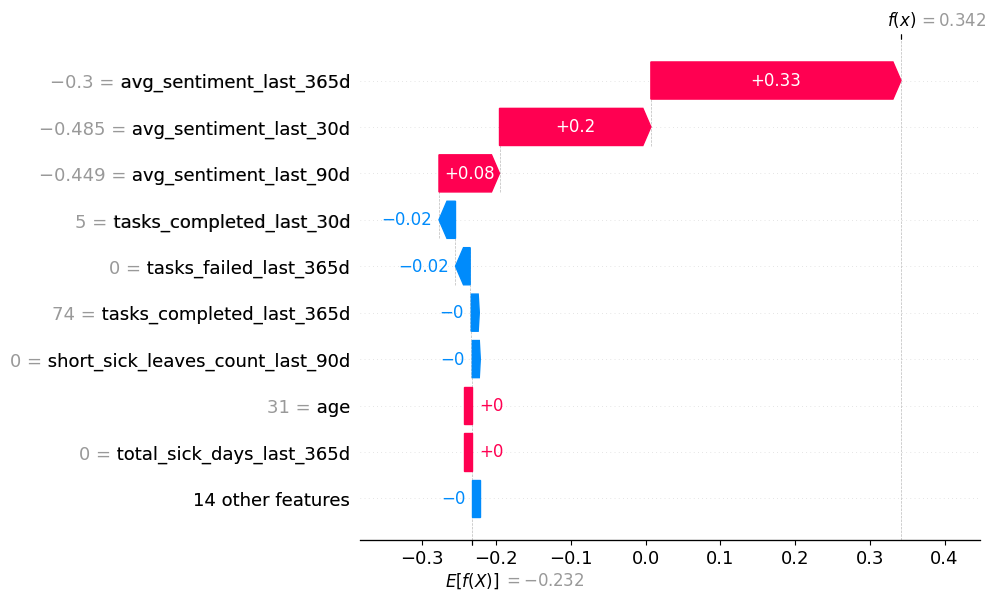

--- Анализ для сотрудника ID: 1075 ---
Вероятность выгорания: 39.55%

Вклад ключевых факторов в предсказание:


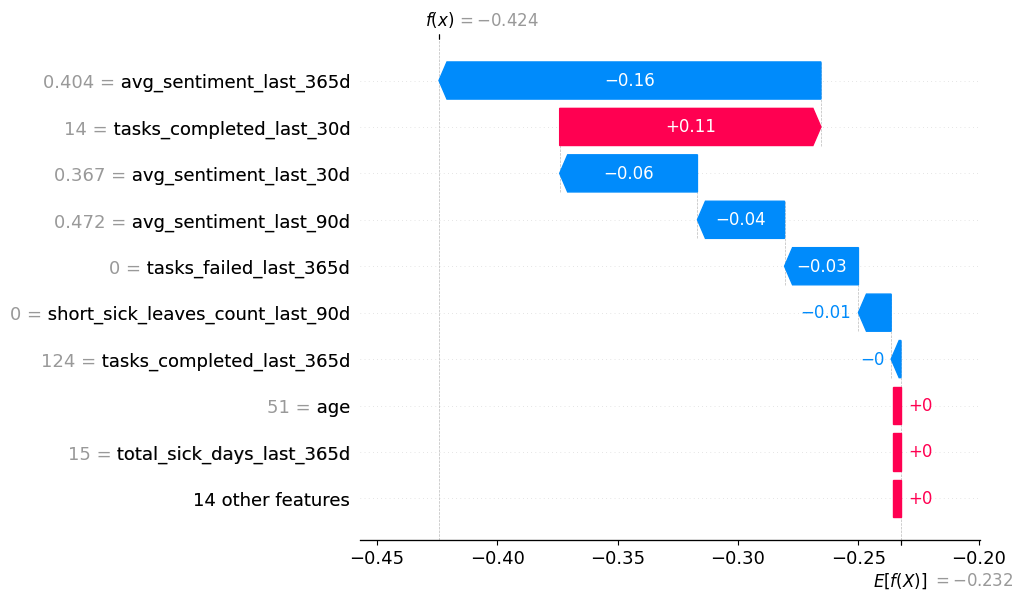

In [17]:
shap.initjs()

explainer = shap.TreeExplainer(model)

def predict_and_explain(employee_data_row):
    if 'employee_id' in employee_data_row.index:
        employee_id = employee_data_row['employee_id']
        features_for_prediction = employee_data_row.drop(['burnout_risk', 'employee_id'])
    else:
        employee_id = "Unknown"
        features_for_prediction = employee_data_row

    prediction_proba = model.predict_proba(features_for_prediction.to_frame().T)[0, 1]
    
    shap_values = explainer.shap_values(features_for_prediction.to_frame().T)
    
    explanation = shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=features_for_prediction,
        feature_names=features_for_prediction.index.tolist()
    )
    
    print(f"--- Анализ для сотрудника ID: {employee_id} ---")
    print(f"Вероятность выгорания: {prediction_proba:.2%}")
    
    print("\nВклад ключевых факторов в предсказание:")
    shap.plots.waterfall(explanation, max_display=10)
    
    return {
        "employee_id": employee_id,
        "burnout_probability": prediction_proba,
        "shap_explanation": explanation
    }


high_risk_employee = df[df['burnout_risk'] == 1].sample(1).iloc[0]
explanation_data = predict_and_explain(high_risk_employee)

low_risk_employee = df[df['burnout_risk'] == 0].sample(1).iloc[0]
explanation_data_low = predict_and_explain(low_risk_employee)